# S&P 500 "#1 Company" Backtester — 1975–2026

Quarterly $500 DCA into **the largest S&P 500 company at the previous quarter-end close**, alongside $500/quarter into the S&P 500 total-return index, valued on **2026-01-02**. Three rules:

- **baseline hold** — keep every lot to the end;
- **25% trailing stop** — at a quarterly check, a lot ≥25% below its highest quarterly-check price since purchase is sold and the proceeds go to the index;
- **buy the dip** — the first time a lot is 25% / 50% below its peak, add new money equal to that lot's original purchase.

Plus a top-10 equal-weight variant (2006–2026, the window with complete top-10 lists).

The logic lives in the `sp500bt/` package; this notebook wires it together. Findings, data-quality attribution and every caveat are in **[REPORT.md](REPORT.md)**.

## How the inputs were built (run once, in order)

| Step | Script | Output |
|---|---|---|
| Sources | `python scripts/fetch_sources.py` | `data/sources/*` (Wikipedia/FT, companiesmarketcap, Shiller, AT&T price table). Browser-only extractions are documented in `data/sources/README.md` |
| Prices | `python scripts/cache_prices.py` | `data/price_cache/*.parquet` + `results/data_quality/price_fetch_report.csv` (every failure listed) |
| Manual series | `python scripts/build_manual_prices.py` | `data/manual_prices/{T_OLD,T_CORP,SPX_TR}.csv` |
| Phase 1 | `python scripts/build_top_table.py` | `data/largest_company_by_quarter.csv`, `data/top1_transitions.csv` |
| Checks | `python scripts/check_prices.py` | `results/data_quality/price_sanity.csv` |
| Scenarios | `python -m sp500bt.run --all` | `results/<family>/`, `charts/<family>/`, `results/scenario_comparison.csv`, `results/all_runs.csv` (see `scenarios/index.csv`) |

Status of the three data problems the original notebook warned about:

1. **Point-in-time #1 table** — sourced, one row per quarter start, each with a confidence grade and (for LOW rows) an alternate pick. 1975–1995 rests on my own market-cap estimates from filings, checked against Morgan Stanley/FactSet year-end ranks, Dimensional/CRSP decade snapshots and Business Week/Forbes rankings.
2. **Survivorship / corporate actions** — the 1984 AT&T breakup and the 2005 SBC merger are modelled explicitly (`data/corporate_actions.csv`); spinoffs inside Yahoo's adjusted series are documented and checked.
3. **Total return** — Yahoo `Adj Close` for stocks; for the index, ^GSPC + Shiller dividends before 1988 spliced onto ^SP500TR (tracks ^SP500TR within 0.06%/yr over 1988–2023).

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from sp500bt.config import AS_OF_DATE, CONTRIB_AMOUNT, START_DATE
from sp500bt.corporate_actions import load_corporate_actions
from sp500bt.engine import RULES, PriceBook, attribution, simulate
from sp500bt.holdings import load_top_holdings, top1_picker, top10_picker
from sp500bt.report import summarize

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print(START_DATE, "->", AS_OF_DATE, f"${CONTRIB_AMOUNT:,.0f}/quarter per leg")

1975-01-01 -> 2026-01-02 $500/quarter per leg


## Phase 1 table: who was #1, and how sure are we?

In [10]:
holdings = load_top_holdings()
display(pd.crosstab(holdings["date"].dt.year // 10 * 10, holdings["confidence"]))
display(holdings.loc[holdings.confidence == "LOW",
        ["date", "top1_ticker", "alt_top1_ticker", "margin_pct", "anchors", "notes"]])

confidence,HIGH,LOW,MEDIUM
date,,,
1970,3,3,14
1980,12,1,27
1990,9,6,25
2000,25,1,14
2010,38,0,2
2020,25,0,0


,date,top1_ticker,alt_top1_ticker,margin_pct,anchors,notes
0,1975-01-01,T_OLD,IBM,-0.8000,ms=T_OLD,estimate ranks IBM first by 0.8%; ms say T_OLD...
10,1977-07-01,T_OLD,IBM,1.0000,NaN,NaN
15,1978-10-01,T_OLD,IBM,1.5000,NaN,NaN
23,1980-10-01,T_OLD,IBM,1.7000,NaN,NaN
63,1990-10-01,XOM,IBM,1.7000,NaN,NaN
64,1991-01-01,IBM,XOM,-1.0000,ms=IBM,estimate ranks XOM first by 1.1%; ms say IBM
69,1992-04-01,XOM,MO,-0.1000,NaN,dead heat (0.12%); incumbent XOM kept
75,1993-10-01,GE,XOM,0.4000,NaN,dead heat (0.41%) between GE and XOM
79,1994-10-01,T_CORP,GE,2.8000,NaN,NaN
83,1995-10-01,GE,T_CORP,1.7000,NaN,NaN


## Corporate actions applied by the engine

Active modes (`value_split`, `stock`, `cash`, `bankruptcy`) change positions; `yahoo_adjusted` / `info` rows document events already inside Yahoo's adjusted prices.

In [11]:
corp_actions = load_corporate_actions()
corp_actions[["old_ticker", "event_date", "mode", "new_ticker", "ratio", "cash_per_share", "notes"]]

,old_ticker,event_date,mode,new_ticker,ratio,cash_per_share,notes
0,T_OLD,1984-01-01,value_split,T_CORP,0.2867,0.0000,Bell System divestiture: new AT&T Corp keeps 1...
1,T_OLD,1984-01-01,value_split,T,0.4637,0.0000,Regional Bells whose value ended up in AT&T In...
2,T_OLD,1984-01-01,value_split,VZ,0.2496,0.0000,Regional Bells whose value ended up in Verizon...
3,T_CORP,1996-09-30,info,NaN,0.0000,0.0000,Lucent spin-off (0.32408 LU/sh): inside T_CORP...
4,T_CORP,1997-01-02,info,NaN,0.0000,0.0000,NCR spin-off (0.0625 NCR/sh): inside T_CORP se...
5,XOM,1999-11-30,info,NaN,0.0000,0.0000,Exxon acquires Mobil (1.32015 XOM per MOB); Ex...
6,T_CORP,2001-07-09,info,NaN,0.0000,0.0000,AT&T Wireless spin-off (0.3218 AWE/sh): inside...
7,T_CORP,2002-11-18,info,NaN,0.0000,0.0000,AT&T Broadband -> Comcast (0.3235 CMCSA/sh) + ...
8,T_CORP,2005-11-18,stock,T,0.7794,0.0000,"SBC Communications acquires AT&T Corp, 0.77942..."
9,T_CORP,2005-11-18,cash,NaN,0.0000,1.3000,$1.30 special dividend paid by AT&T Corp on th...


## Phase 4: the three rules, 1975–2026

In [12]:
prices = PriceBook()
runs = {rule: simulate(top1_picker, fn, holdings, corp_actions, prices=prices) for rule, fn in RULES.items()}
summary = pd.DataFrame([summarize(r, f"top1_{rule}") for rule, r in runs.items()]).set_index("scenario")
summary[["strategy_invested", "strategy_value", "strategy_multiple", "strategy_xirr",
         "index_invested", "index_leg_value", "index_xirr", "total_value", "total_xirr", "stop_outs", "dip_adds"]]

,strategy_invested,strategy_value,strategy_multiple,strategy_xirr,index_invested,index_leg_value,index_xirr,total_value,total_xirr,stop_outs,dip_adds
scenario,,,,,,,,,,,
top1_baseline_hold,"102,500.0000","2,460,375.3140",24.0037,0.0973,"102,500.0000","5,508,523.1373",0.1187,"7,968,898.4513",0.1102,0,0
top1_trailing_stop_25,"102,500.0000","5,200,079.1553",50.7325,0.1172,"102,500.0000","5,508,523.1373",0.1187,"10,708,602.2926",0.1180,222,0
top1_buy_the_dip_25_50,"270,499.9840","5,565,831.8506",20.5761,0.1028,"102,500.0000","5,508,523.1373",0.1187,"11,074,354.9879",0.1100,0,400


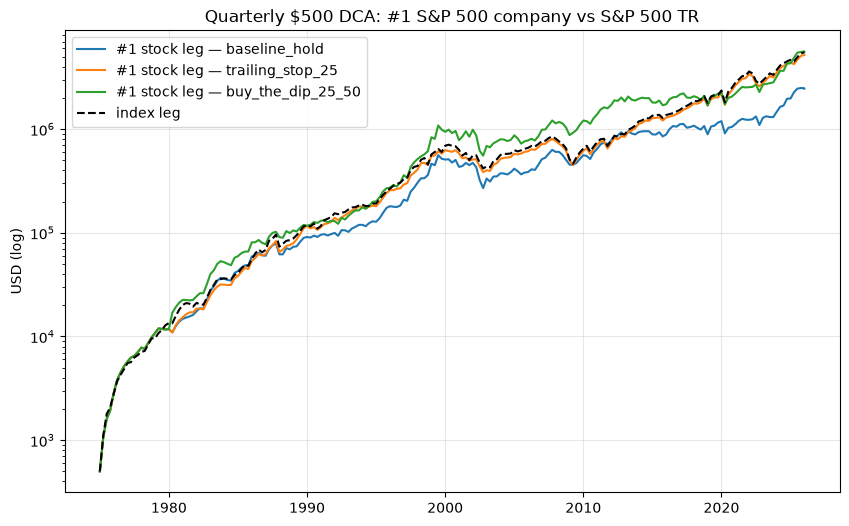

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
for rule, r in runs.items():
    ax.plot(r.valuations.index, r.valuations["strategy_value"], label=f"#1 stock leg — {rule}")
ax.plot(r.valuations.index, r.valuations["index_leg_value"], "k--", label="index leg")
ax.set_yscale("log")
ax.set_ylabel("USD (log)")
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("Quarterly $500 DCA: #1 S&P 500 company vs S&P 500 TR")
plt.show()

### How much of the ending value rests on each confidence grade?
Ending value of the stock leg, attributed to the confidence of the Phase 1 row that triggered each original purchase (children of corporate actions and stop-loss proceeds keep their origin).

In [14]:
attr = pd.DataFrame({rule: attribution(r, prices) for rule, r in runs.items()})
display(attr.round(0))
(attr / attr.sum()).round(3)  # share of ending value by origin-row confidence

,baseline_hold,trailing_stop_25,buy_the_dip_25_50
HIGH,"668,433.0000","1,101,364.0000","1,740,313.0000"
LOW,"299,741.0000","734,278.0000","398,557.0000"
MEDIUM,"1,492,201.0000","3,364,438.0000","3,426,962.0000"


,baseline_hold,trailing_stop_25,buy_the_dip_25_50
HIGH,0.2720,0.2120,0.3130
LOW,0.1220,0.1410,0.0720
MEDIUM,0.6060,0.6470,0.6160


## Top-10 equal-weight variant (2006-04-01 onward — the COMPLETE top-10 window)

In [15]:
start10 = "2006-04-01"
rows = []
for rule, fn in RULES.items():
    for picker, name in ((top10_picker, f"top10_{rule}"), (top1_picker, f"top1_{rule}_same_window")):
        res = simulate(picker, fn, holdings, corp_actions, start=start10, prices=prices)
        rows.append(summarize(res, name))
cols = ["strategy_invested", "strategy_value", "strategy_xirr", "index_xirr", "total_xirr"]
pd.DataFrame(rows).set_index("scenario")[cols]

,strategy_invested,strategy_value,strategy_xirr,index_xirr,total_xirr
scenario,,,,,
top10_baseline_hold,"40,000.0000","207,746.0597",0.1467,0.1341,0.1407
top1_baseline_hold_same_window,"40,000.0000","230,590.2426",0.1553,0.1341,0.1454
top10_trailing_stop_25,"40,000.0000","165,583.5891",0.1280,0.1341,0.1311
top1_trailing_stop_25_same_window,"40,000.0000","153,060.3912",0.1214,0.1341,0.1280
top10_buy_the_dip_25_50,"76,200.0000","402,164.7671",0.1600,0.1341,0.1509
top1_buy_the_dip_25_50_same_window,"84,500.0000","470,083.0134",0.1730,0.1341,0.1596


## Full scenario grid (sensitivities)
`python -m sp500bt.run --all` runs every scenario family, including each sensitivity (LOW rows → alternates, confidence gates, pre-1996 rows → index, AT&T divestiture treatments, alternative windows). Its output:

In [16]:
grid = pd.read_csv("results/all_runs.csv").set_index("scenario")
grid[["family", "group", "strategy_xirr", "index_xirr", "strategy_value", "total_xirr"]]

,group,strategy_xirr,index_xirr,strategy_value,total_xirr
scenario,,,,,
top1_baseline_hold,main,0.0973,0.1187,"2,460,375.3140",0.1102
top1_trailing_stop_25,main,0.1172,0.1187,"5,200,079.1553",0.1180
top1_buy_the_dip_25_50,main,0.1028,0.1187,"5,565,831.8506",0.1100
top10_ew_baseline_hold,top10,0.1467,0.1341,"207,746.0597",0.1407
top1_baseline_hold_from_2006,top10,0.1553,0.1341,"230,590.2426",0.1454
top10_ew_trailing_stop_25,top10,0.1280,0.1341,"165,583.5891",0.1311
top1_trailing_stop_25_from_2006,top10,0.1214,0.1341,"153,060.3912",0.1280
top10_ew_buy_the_dip_25_50,top10,0.1600,0.1341,"402,164.7671",0.1509
top1_buy_the_dip_25_50_from_2006,top10,0.1730,0.1341,"470,083.0134",0.1596
